    # <b>Municipal Water Use Analysis Capstone Project</b>

Author: Viviane Baji
Date: March 2026
<br>Environmental Data Science Certificate Program, Yale School of the Environment, Cohort 1</br>

## Environmental Research Questions: 

- What kinds of cities are decreasing their per capita water use?
- Does this vary spatially?

Link to GitHub repository: [GitHub Repository](<https://github.com/viviane-acct/EDScapstone>)


## Loading Libraries

In [3]:
#load libraries
library(tidyr) #data organization
library(ggplot2) #data visualization
library(dplyr) #data cleaning
library(GGally) #statistics
library(janitor) #data cleaning
library(lubridate) #dates
library(stringr) #strings
library(naniar) #missingness
library(fixest) #fast estimation of linear models

#more data viz libraries
library(ggrepel)      #for smart label placement
library(scales)       #for nice axis formatting
library(sf)           #for maps 
library(ggrepel)      #repel on maps

#set a clean theme as default
theme_set(theme_minimal(base_size = 14))


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union





Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test





Attaching package: ‘lubridate’




The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union





Attaching package: ‘scales’




The following object is masked from ‘package:fixest’:

    pvalue




Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



## Loading Data

In [4]:
#check directory
getwd()

[1] "/home/user/EDScapstone/scripts"

In [5]:
#navigate to raw_data

setwd("/home/user/EDScapstone/raw_data")
my_wd <- getwd()

#see files in directory
raw_files <- list.files(my_wd)

raw_files

[1] "annual_water_use_no_missing_city_data.csv"            
 [2] "cb_2018_us_state_20m"                                 
 [3] "cb_2018_us_ua10_500k"                                 
 [4] "Cities shapefile"                                     
 [5] "Cities shapefile.zip"                                 
 [6] "cities_missing_data_census_id.csv"                    
 [7] "cities_missing_data.csv"                              
 [8] "City-characteristics.csv"                             
 [9] "Municipal_Water_Uses_clean3.csv"                      
[10] "Municipal_water_uses_dataset_2005-2017.csv"           
[11] "old"                                                  
[12] "Primary Water Rights Systems in the United States.pdf"
[13] "readme.md"                                            
[14] "states_groundwater_rights.csv"                        
[15] "states_surface_water_rights.csv"                      
[16] "tl_2020_us_uac20"                                     
[17] "tl_2020_us_uac20.zip"

There are three main datasets for my capstone project. The first is a csv file with monthly municipal billing records for 126 cities across the continuous United States; broken out by residential, cii, master, and total. 

There are three main datasets for my capstone project. I will load each of them into this notebook and explore/clean as needed before joining them where needed to continue the analysis. All of these datasets come from the same source which helps with trusting that they can relate to each other, provided I use the correct keys.

-  The first is a csv file with monthly municipal billing records for 126 cities across the continuous United States; broken out by residential, cii, master, and total.
-  The second is a csv file with information about all of the cities; including climate and housing data and land cover.
-  The third is a shapefile file with point data for 126 cities across the continuous United States that there is municipal water use data for.


In [6]:
#create dataframe for municipal water uses dataset
muni_water<-read.csv("Municipal_water_uses_dataset_2005-2017.csv")

glimpse(muni_water)

#see number unique cities
n_distinct(muni_water$city)

#data names are not all in the same format 
#date is shown as string, not date format
#should also separate city and state in dataset

Rows: 16,305
Columns: 8
$ USCensusID            <chr> "1600000US4801000", "1600000US4801000", "1600000…
$ city                  <chr> "Abilene, Texas", "Abilene, Texas", "Abilene, Te…
$ date                  <chr> "1/1/2005", "2/1/2005", "3/1/2005", "4/1/2005", …
$ population            <dbl> 120267, 120267, 120267, 120267, 120267, 120267, …
$ res_billed_gallons    <dbl> 193610000, 168050000, 158100000, 190420000, 2601…
$ cii_billed_gallons    <dbl> 202640000, 198560000, 161420000, 191640000, 2106…
$ master_billed_gallons <dbl> 64870000, 51900000, 47580000, 68730000, 68170000…
$ total_billed_gallons  <dbl> 461120000, 418510000, 367100000, 450790000, 5389…


[1] 126

In [7]:
#create dataframe for city characteristics dataset
city_char <-read.csv("City-characteristics.csv")

head(city_char)

,USCensusID,City,CII.RES,US_census_region,Climate_region,Avg_population,January.precipitation,February.precipitation,March.precipitation,April.precipitation,⋯,Percent.housing.units.built.between.1950.1989,Percent.housing.units.built.before.1950,Percent.housing.units.built.earlier.to.1990,Median.rooms,Percent.impervious.area,Area.open.NLCD,Area.low.development.NLCD,Area.medium.development.NLCD,Area.high.development.NLCD,Service.area.sq.meters
,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1600000US4801000,"Abilene city, Texas",0.727,South,Temperate,123729,25.9,35.6,42.5,45.8,⋯,63.3,14.7,78.0,5.3,16.4,13874.8,10720.6,6208.8,3755.7,290335000
2,1600000US4500550,"Aiken city, South Carolina",NA,South,Temperate,29406,110.8,103.6,111.3,84.8,⋯,49.6,7.1,56.7,6.0,9.0,7626.2,6274.4,1805.4,573.7,194774000
3,1600000US3501780,"Alamogordo city, New Mexico",0.205,West,Arid,32986,17.7,12.9,9.5,8.9,⋯,69.3,4.5,73.8,5.4,14.4,1792.0,3050.2,965.0,208.4,56002000
4,1600000US3502000,"Albuquerque city, New Mexico",0.380,West,Arid,614980,10.8,11.8,14.6,17.3,⋯,57.6,7.2,64.8,5.3,26.9,11553.2,32002.9,24592.5,5344.4,489188000
5,1600000US4202184,"Altoona city, Pennsylvania",0.454,Northeast,Continental,54369,65.2,55.3,79.2,80.0,⋯,37.1,58.7,95.8,6.1,18.9,4855.7,6346.8,3384.4,1673.1,131990000
6,1600000US4803000,"Amarillo city, Texas",0.653,South,Arid,196728,17.0,15.3,30.3,32.7,⋯,62.3,14.9,77.2,5.1,25.2,7145.7,19825.2,7535.3,4717.4,266556000


In [8]:
#bring in city characteristics shapefile for mapping

#change directory
setwd("/home/user/EDScapstone/raw_data/Cities shapefile")
my_city_shapefile <- getwd()

#see files in directory
city_shapefile_files <- list.files(my_city_shapefile)
city_shapefile_files

[1] "MunicipalWaterUseCharacterizationCities.cpg"    
[2] "MunicipalWaterUseCharacterizationCities.dbf"    
[3] "MunicipalWaterUseCharacterizationCities.prj"    
[4] "MunicipalWaterUseCharacterizationCities.sbn"    
[5] "MunicipalWaterUseCharacterizationCities.sbx"    
[6] "MunicipalWaterUseCharacterizationCities.shp"    
[7] "MunicipalWaterUseCharacterizationCities.shp.xml"
[8] "MunicipalWaterUseCharacterizationCities.shx"

In [9]:
#read in city characteristics shapefile
city_char_shp <- st_read("/home/user/EDScapstone/raw_data/Cities shapefile/MunicipalWaterUseCharacterizationCities.shp")

str(city_char_shp)

#see number unique cities
n_distinct(city_char_shp$City)

Reading layer `MunicipalWaterUseCharacterizationCities' from data source 
  `/home/user/EDScapstone/raw_data/Cities shapefile/MunicipalWaterUseCharacterizationCities.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 126 features and 4 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -122.71 ymin: 25.76 xmax: -68.79 ymax: 48.59
Geodetic CRS:  NAD83


Classes ‘sf’ and 'data.frame':	126 obs. of  5 variables:
 $ USCensusID: chr  "1600000US4801000" "1600000US4500550" "1600000US3501780" "1600000US3502000" ...
 $ City      : chr  "Abilene city, Texas" "Aiken city, South Carolina" "Alamogordo city, New Mexico" "Albuquerque city, New Mexico" ...
 $ latitude  : num  32.5 33.5 32.9 35.1 40.5 ...
 $ longitude : num  -99.7 -81.7 -106 -106.7 -78.4 ...
 $ geometry  :sfc_POINT of length 126; first list element:  'XY' num  -99.7 32.5
 - attr(*, "sf_column")= chr "geometry"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA
  ..- attr(*, "names")= chr [1:4] "USCensusID" "City" "latitude" "longitude"


[1] 126

## Municipal Water Use Dataset Data Cleaning

### Formatting

In [10]:
#first, format muni_water to follow standard naming conventions and check that data types are correct
#rename to snake case
muni_water_clean<-clean_names(muni_water,"snake")

head(muni_water_clean)

#convert date to date format from string
muni_water_clean <- muni_water_clean %>%
    mutate(
    date = as.Date(date, format="%m/%d/%Y"))

#data types now look correct, variables show as numeric, indicating NA values are treated correctly
#the data looks to be available at a monthly timeset according to the date column. The billed water use columns seem to follow that formet with different numbers for each month. The population number, however, looks to be the same for each month. It could be an annual population. 

,us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1600000US4801000,"Abilene, Texas",1/1/2005,120267,193610000,202640000,64870000,461120000
2,1600000US4801000,"Abilene, Texas",2/1/2005,120267,168050000,198560000,51900000,418510000
3,1600000US4801000,"Abilene, Texas",3/1/2005,120267,158100000,161420000,47580000,367100000
4,1600000US4801000,"Abilene, Texas",4/1/2005,120267,190420000,191640000,68730000,450790000
5,1600000US4801000,"Abilene, Texas",5/1/2005,120267,260170000,210640000,68170000,538980000
6,1600000US4801000,"Abilene, Texas",6/1/2005,120267,283130000,227100000,102870000,613100000


### Missingness

In [11]:
#next, investigate missingness in data

#Get 5-number stats on muni_water_clean
summary(muni_water_clean)

 us_census_id           city                date              population     
 Length:16305       Length:16305       Min.   :2005-01-01   Min.   :   2718  
 Class :character   Class :character   1st Qu.:2008-12-01   1st Qu.:  38617  
 Mode  :character   Mode  :character   Median :2012-03-01   Median : 110990  
                                       Mean   :2011-12-18   Mean   : 353600  
                                       3rd Qu.:2015-02-01   3rd Qu.: 340269  
                                       Max.   :2017-12-01   Max.   :8622698  
                                                                             
 res_billed_gallons  cii_billed_gallons  master_billed_gallons
 Min.   :3.915e+06   Min.   :2.323e+06   Min.   :7.480e+02    
 1st Qu.:8.974e+07   1st Qu.:7.108e+07   1st Qu.:1.401e+07    
 Median :2.663e+08   Median :2.025e+08   Median :7.280e+07    
 Mean   :6.647e+08   Mean   :4.997e+08   Mean   :1.212e+08    
 3rd Qu.:8.364e+08   3rd Qu.:5.037e+08   3rd Qu.:1.519e+08   

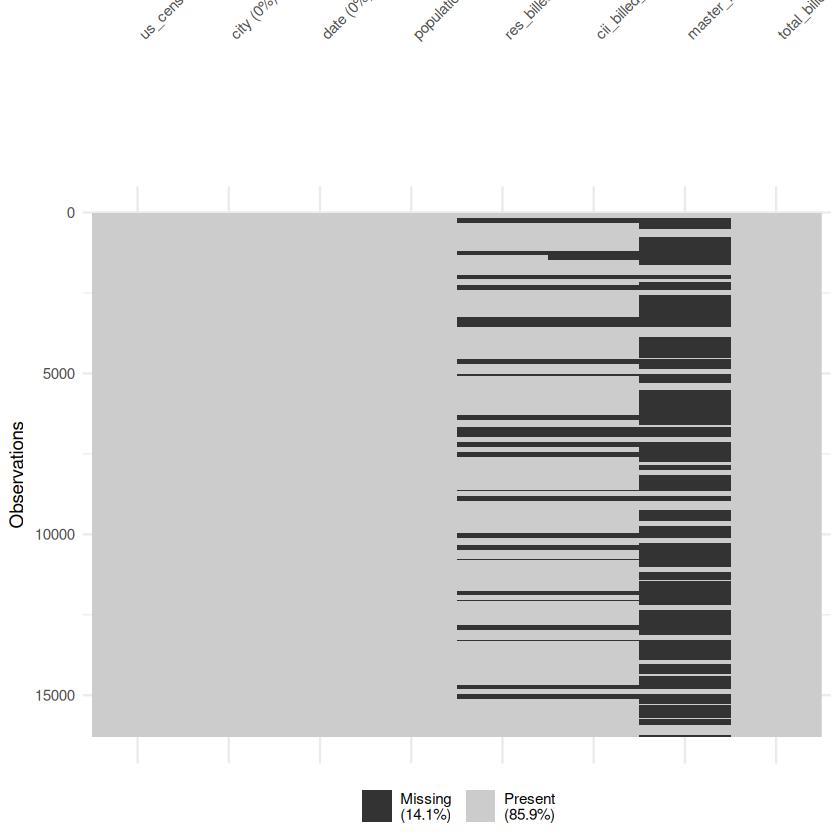

In [12]:
#visualize missingness using vis_miss()
vis_miss(muni_water_clean)

### Municipal water use dataset missingness discussion
- master_billed variable has the most missing data

- res_billed and cii_billed have same number of values

- visualization shows all res_billed and cii_billed NAs also have NA for master_billed

- total_billed_gallons is not missing any values which is helpful in determining the relationship between the broken out water use categores compared to the total

- It is very possible that the more detailed data could not be obtained for all of the cities. In some cases there might be a difference in interpretation between the more well-known categories (res_billed and cii_billed) while master_billed seems to have more missing values.

Metadata Review: After consulting metadata it looks like total_billed_gallons = cii_billed_gallons + res_billed_gallons + master_billed_gallons. Master_billed_gallons is more like water that did not go to a specific sector. There could be differences in city reporting on master_billed_gallons and could be part of the res or cii sectors in some cities. This is something to keep in mind when interpreting any results from the analysis that uses those non-residential sectors.

Conclusion: My analysis is going to focus on the <b>residential</b> sector so the master_billed missingness is not an issue. However, I will need to be mindful with calculations to treat the NA values in the residential water use column properly. In this case there is a lot of data from most of the cities for residential so I do not feel it is necessary to impute any data. Instead, I will exclude NA values from the analysis. This could potentially reduce the accuracy of my results, especially because I suspect it's because certain cities did not want to share the more detailed information so it's a systematic error. This should be noted in any findings.

Follow-on work: this evaluation of missingness focuses on the dataset as it is and the existing NA values. More work is needed to determine if there is data that is truly missing from the dataset, such as a city that maybe only has data from 2010-2017. 

### Annual municipal water use dataset missingness
I need to check if there are years in the dataset timeframe that are missing for any city. I will generate an annual water use dataframe from the existing monthly dataframe to see the missing data
- make sure to get ONE population value from each year, not the sum of each monthly timestep

In [14]:
#Need to check if there are years in the dataset timeframe that are missing for any city

#add year from existing date and city columns 
muni_water_clean<- muni_water_clean%>%
    mutate(
        year = year(date))                             # Extract year as separate column

head(muni_water_clean,10)

#get end-of-year population by extracting December population. Can't sum up the monthly population since it is the same value and would lead to incorrect calculations

#get month as index 1-12
muni_water_clean <- muni_water_clean %>%
    mutate(
        month_index = as.integer(format(date, "%m")
    )) 

#add column for end of year population. Important if I want to summarize by year and avoid duplicating population X 12
muni_water_clean <- muni_water_clean %>%
    mutate(
        pop_eoy = ifelse(    #end of year population
            month_index == 12,   #if month is December
            population,         # show population
            NA                   # otherwise end of year population is NA
        )
    )



,us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,month_index,pop_eoy
,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,1600000US4801000,"Abilene, Texas",2005-01-01,120267,193610000,202640000,64870000,461120000,2005,1,NA
2,1600000US4801000,"Abilene, Texas",2005-02-01,120267,168050000,198560000,51900000,418510000,2005,2,NA
3,1600000US4801000,"Abilene, Texas",2005-03-01,120267,158100000,161420000,47580000,367100000,2005,3,NA
4,1600000US4801000,"Abilene, Texas",2005-04-01,120267,190420000,191640000,68730000,450790000,2005,4,NA
5,1600000US4801000,"Abilene, Texas",2005-05-01,120267,260170000,210640000,68170000,538980000,2005,5,NA
6,1600000US4801000,"Abilene, Texas",2005-06-01,120267,283130000,227100000,102870000,613100000,2005,6,NA
7,1600000US4801000,"Abilene, Texas",2005-07-01,120267,395900000,251530000,95350000,742780000,2005,7,NA
8,1600000US4801000,"Abilene, Texas",2005-08-01,120267,382110000,248490000,77860000,708460000,2005,8,NA
9,1600000US4801000,"Abilene, Texas",2005-09-01,120267,283240000,241620000,86260000,611120000,2005,9,NA


In [15]:
#get annual water use dataset
annual_water_use <- muni_water_clean%>%
    group_by(city,us_census_id,year) %>%       #group by city first to match order of original data
    summarise(
        res_gal= sum(res_billed_gallons, na.rm= TRUE),
        cii_gal= sum(cii_billed_gallons, na.rm= TRUE),
        master_gal= sum(master_billed_gallons, na.rm= TRUE),
        total_gal= sum(total_billed_gallons, na.rm= TRUE),
        total_pop= sum(pop_eoy, na.rm= TRUE)      #use end of year population
    )

head(annual_water_use)

`summarise()` has grouped output by 'city', 'us_census_id'. You can override
using the `.groups` argument.


city,us_census_id,year,res_gal,cii_gal,master_gal,total_gal,total_pop
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"Abilene, Texas",1600000US4801000,2005,3130906000,2614567000,877646000,6623119000,120267
"Abilene, Texas",1600000US4801000,2006,3696448000,2662115000,1028772000,7387335000,121135
"Abilene, Texas",1600000US4801000,2007,2679991000,2416515000,954743000,6051249000,122003
"Abilene, Texas",1600000US4801000,2008,3091783000,2576146000,1035345000,6703274000,122871
"Abilene, Texas",1600000US4801000,2009,3140937000,2548002000,1010430000,6699369000,123739
"Abilene, Texas",1600000US4801000,2010,2807008000,2360361000,1052125000,6219494000,124607


In [16]:
#pivot_wide by year to see every city residential water use by year
annual_water_use_pivot_wide<- annual_water_use%>%
    select(city, us_census_id, year, res_gal)%>%
        pivot_wider(names_from = year, values_from = res_gal)

head(annual_water_use_pivot_wide)

#total look at annual water use pivot
summary(annual_water_use_pivot_wide)

#pivot_wide by year to see every city population by year
population_pivot_wide<- annual_water_use%>%
    select(city, us_census_id, year, total_pop)%>%
        pivot_wider(names_from = year, values_from = total_pop)

#total look at population pivot
summary(population_pivot_wide)


#some cities do not have the full 2005-2017 timeframe of data for residential water use or population. Same number of NA between water use and popuation is helpful at least.

city,us_census_id,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"Abilene, Texas",1600000US4801000,3130906000,3696448000,2679991000,3091783000,3140937000,2807008000,3765573000,3138153000,2989906000,3380939000,3093902000,3085413000,3032797000
"Aiken, South Carolina",1600000US4500550,0,0,0,0,0,0,0,0,0,0,0,0,0
"Alamogordo, New Mexico",1600000US3501780,1104381780,1002838618,1075079344,1072190979,1087284310,1061717491,1141433392,1107544025,1018136168,1062788268,1010111422,1026061640,968469567
"Albuquerque, New Mexico",1600000US3502000,20805296256,19663927404,20157320920,20200086324,21078785464,20576268624,20726142756,20488195924,19206295020,19093916248,18191445504,19125005372,19252426414
"Altoona, Pennsylvania",1600000US4202184,NA,1215185803,1195025288,1160205731,1160361434,1138912482,1110751269,1078169339,1045587807,1040356872,1050232369,1018358846,987683944
"Amarillo, Texas",1600000US4803000,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,17506214820,21030524000,20536515000


     city           us_census_id            2005                2006          
 Length:126         Length:126         Min.   :0.000e+00   Min.   :0.000e+00  
 Class :character   Class :character   1st Qu.:4.561e+08   1st Qu.:5.012e+08  
 Mode  :character   Mode  :character   Median :2.691e+09   Median :2.731e+09  
                                       Mean   :7.762e+09   Mean   :6.962e+09  
                                       3rd Qu.:1.145e+10   3rd Qu.:9.039e+09  
                                       Max.   :8.933e+10   Max.   :9.439e+10  
                                       NA's   :59          NA's   :41         
      2007                2008                2009          
 Min.   :0.000e+00   Min.   :0.000e+00   Min.   :0.000e+00  
 1st Qu.:3.160e+08   1st Qu.:3.914e+08   1st Qu.:3.872e+08  
 Median :2.630e+09   Median :2.446e+09   Median :2.382e+09  
 Mean   :6.323e+09   Mean   :6.296e+09   Mean   :6.178e+09  
 3rd Qu.:7.216e+09   3rd Qu.:7.231e+09   3rd Qu.:7.824e+09  
 M

     city           us_census_id            2005              2006        
 Length:126         Length:126         Min.   :   8920   Min.   :   6600  
 Class :character   Class :character   1st Qu.:  39484   1st Qu.:  46000  
 Mode  :character   Mode  :character   Median : 120267   Median : 110990  
                                       Mean   : 267938   Mean   : 343241  
                                       3rd Qu.: 339452   3rd Qu.: 311857  
                                       Max.   :1900000   Max.   :8108391  
                                       NA's   :59        NA's   :41       
      2007              2008              2009              2010        
 Min.   :   6700   Min.   :   2746   Min.   :   2718   Min.   :   2739  
 1st Qu.:  43522   1st Qu.:  38848   1st Qu.:  44865   1st Qu.:  38661  
 Median : 109729   Median : 109118   Median : 114984   Median : 111928  
 Mean   : 347928   Mean   : 348193   Mean   : 355880   Mean   : 345430  
 3rd Qu.: 316446   3rd Qu.: 315804 

In [17]:
#export dataframe with missing data for reference/further investigation

#focusing on missing values after 2010 because indicator variable I want to use is not applicable for those early years anyway. This would need to change if the analysis changes. See more discussion in EDA section

years_for_analysis<- c("2010","2011","2012","2013","2014","2015","2016","2017")

cities_missing_data <-
  annual_water_use_pivot_wide %>%
  filter_at(vars(all_of(years_for_analysis)), any_vars(is.na(.)))

unique_cities_missing<-unique(cities_missing_data$city)

print(unique_cities_missing)

 [1] "Amarillo, Texas"                "Annapolis, Maryland"           
 [3] "Auburn, Maine"                  "Augusta, Maine"                
 [5] "Cincinnati, Ohio"               "Denver, Colorado"              
 [7] "Detroit, Michigan"              "Durham, North Carolina"        
 [9] "Enid, Oklahoma"                 "Flagstaff, Arizona"            
[11] "Fort Collins, Colorado"         "Grand Island, Nebraska"        
[13] "Green River, Wyoming"           "Havre, Montana"                
[15] "International Falls, Minnesota" "Las Vegas, Nevada"             
[17] "Los Angeles, California"        "Manchester, New Hampshire"     
[19] "Miami, Florida"                 "Milwaukee, Wisconsin"          
[21] "Minot, North Dakota"            "Montrose, Colorado"            
[23] "Orlando, Florida"               "Plainview, Texas"              
[25] "Ponca City, Oklahoma"           "San Diego, California"         
[27] "San Francisco, California"      "Spokane, Washington"           
[29] "

In [18]:
#check directory
getwd()

[1] "/home/user/EDScapstone/raw_data/Cities shapefile"

In [19]:
#change directory
setwd("/home/user/EDScapstone/processed_data")
getwd()

[1] "/home/user/EDScapstone/processed_data"

In [33]:
#export missing city data for reference
write.csv(cities_missing_data, file = "/home/user/EDScapstone/processed_data/cities_missing_res_data_census_id.csv", row.names = FALSE)

#check that file was successfully generated
list.files("/home/user/EDScapstone/processed_data/")


[1] "cities_missing_res_data_census_id.csv"
[2] "readme.md"

[1] "/home/user/EDScapstone/raw_data"

In [34]:
#navigate back to raw_data folder
setwd(my_wd)
getwd()

[1] "/home/user/EDScapstone/raw_data"

### Annual municipal water use dataset missingness discussion
- There are definitely missing residential and population data for some cities for some years. It looks like it's mostly at the beginning or end of the time period, not so much gaps in the middle. One positive is that the max number of cities in a year with missing data is 22/126 total (from 2010-2017). 

- This investigation shows that any statements about <b>total</b> water use would not be accurate unless the dataset is filtered down to the cities that are not missing any data. For this and other reasons it is more appropriate to show water use per capita to normalize the data and make comparison between cities more useful. I am also thinking about using indicator variables that look consider conditions that occur in <i>any</i> part of the dataset time period. I would need to consider the dataset carefully if I was to be concered about specifc conditions at specific times.

- This has also helped me realize that there is a lot of richness in the existing monthly dataset and compressing it to an annual dataset would make me lose some of that variability while making these missing data issues possibly more prominent.




### Additional Data Cleaning/Investigation after project presentation on March 17th with Professor Eli Fenchel
Professor Fenchel made the following data cleaning suggestions:
- Ensure that all cities reported monthly, not quarterly. The investigation below shows that the billing data is not repeated for months within a quarter, indicating the data is truly monthly.
- Refine scope at the analysis to focus on residential water use specifically, update all figures to reflect that. This has been addressed throughout the workflow. 

In [48]:
#Ensure that all cities reported monthly, not quarterly

#get df with non-NA data
muni_water_clean_no_NA <- muni_water_clean%>%
    filter(!is.na(res_billed_gallons) )

#arrange data by city, date
muni_water_clean_no_NA <- muni_water_clean_no_NA %>%
arrange(city,date)

head(muni_water_clean_no_NA %>%
    filter(city == "Tucson, Arizona")   #test a city
     )

#check that data is not duplicated in row above, using lag function
muni_water_clean_no_NA <- muni_water_clean_no_NA %>%
  mutate(
      res_not_same_as_above = res_billed_gallons != lag(res_billed_gallons),  #this is what I'm interested in
      total_not_same_as_above = total_billed_gallons != lag(total_billed_gallons) #this helps to verify that it is a true duplicate and not a billing rounding issue
        )

head(muni_water_clean_no_NA %>%
    filter(res_not_same_as_above == "FALSE" & total_not_same_as_above == "FALSE"))  

#results show that the billing data is not repeated for months within a quarter, indicating the data is truly monthly

,us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,month_index,pop_eoy
,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,1600000US0477000,"Tucson, Arizona",2005-01-01,644414,1826147363,567247461,NA,2393394824,2005,1,NA
2,1600000US0477000,"Tucson, Arizona",2005-02-01,644414,1675629956,572126500,NA,2247756456,2005,2,NA
3,1600000US0477000,"Tucson, Arizona",2005-03-01,644414,1793311898,729594862,NA,2522906760,2005,3,NA
4,1600000US0477000,"Tucson, Arizona",2005-04-01,644414,2048443688,646051430,NA,2694495118,2005,4,NA
5,1600000US0477000,"Tucson, Arizona",2005-05-01,644414,2368145500,986723362,NA,3354868862,2005,5,NA
6,1600000US0477000,"Tucson, Arizona",2005-06-01,644414,2835663093,1209856834,NA,4045519927,2005,6,NA


us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,month_index,pop_eoy,res_not_same_as_above,total_not_same_as_above
<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<lgl>,<lgl>


## City Characteristics Dataset Cleaning

In [32]:
#rename to snake case
city_char_clean<-clean_names(city_char,"snake")

head(city_char_clean)
#summary(city_char_clean) #run if summary of all columns needed

#see number unique cities
n_distinct(city_char_clean$city)

#all 126 cities are in the city characteristics dataset. Characteristics are present for all cities, except for the cii_res in a few cases. For the purposes of this capstone I am going to focus on one or two variables from this dataset to describe the municipal water use, but there is a lot of potential here for further analysis!

,us_census_id,city,cii_res,us_census_region,climate_region,avg_population,january_precipitation,february_precipitation,march_precipitation,april_precipitation,⋯,percent_housing_units_built_between_1950_1989,percent_housing_units_built_before_1950,percent_housing_units_built_earlier_to_1990,median_rooms,percent_impervious_area,area_open_nlcd,area_low_development_nlcd,area_medium_development_nlcd,area_high_development_nlcd,service_area_sq_meters
,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1600000US4801000,"Abilene city, Texas",0.727,South,Temperate,123729,25.9,35.6,42.5,45.8,⋯,63.3,14.7,78.0,5.3,16.4,13874.8,10720.6,6208.8,3755.7,290335000
2,1600000US4500550,"Aiken city, South Carolina",NA,South,Temperate,29406,110.8,103.6,111.3,84.8,⋯,49.6,7.1,56.7,6.0,9.0,7626.2,6274.4,1805.4,573.7,194774000
3,1600000US3501780,"Alamogordo city, New Mexico",0.205,West,Arid,32986,17.7,12.9,9.5,8.9,⋯,69.3,4.5,73.8,5.4,14.4,1792.0,3050.2,965.0,208.4,56002000
4,1600000US3502000,"Albuquerque city, New Mexico",0.380,West,Arid,614980,10.8,11.8,14.6,17.3,⋯,57.6,7.2,64.8,5.3,26.9,11553.2,32002.9,24592.5,5344.4,489188000
5,1600000US4202184,"Altoona city, Pennsylvania",0.454,Northeast,Continental,54369,65.2,55.3,79.2,80.0,⋯,37.1,58.7,95.8,6.1,18.9,4855.7,6346.8,3384.4,1673.1,131990000
6,1600000US4803000,"Amarillo city, Texas",0.653,South,Arid,196728,17.0,15.3,30.3,32.7,⋯,62.3,14.9,77.2,5.1,25.2,7145.7,19825.2,7535.3,4717.4,266556000


[1] 126

## City Shapefile Dataset Cleaning

In [22]:
#rename to snake case
city_char_shp_clean<-clean_names(city_char_shp,"snake")

head(city_char_shp_clean)
glimpse(city_char_shp_clean)

#see number unique cities
n_distinct(city_char_shp_clean$city)

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



,us_census_id,city,latitude,longitude,geometry
,<chr>,<chr>,<dbl>,<dbl>,<POINT [°]>
1,1600000US4801000,"Abilene city, Texas",32.45,-99.74,POINT (-99.74 32.45)
2,1600000US4500550,"Aiken city, South Carolina",33.53,-81.73,POINT (-81.73 33.53)
3,1600000US3501780,"Alamogordo city, New Mexico",32.88,-105.96,POINT (-105.96 32.88)
4,1600000US3502000,"Albuquerque city, New Mexico",35.10,-106.65,POINT (-106.65 35.1)
5,1600000US4202184,"Altoona city, Pennsylvania",40.51,-78.40,POINT (-78.4 40.51)
6,1600000US4803000,"Amarillo city, Texas",35.20,-101.83,POINT (-101.83 35.2)


Rows: 126
Columns: 5
$ us_census_id <chr> "1600000US4801000", "1600000US4500550", "1600000US3501780…
$ city         <chr> "Abilene city, Texas", "Aiken city, South Carolina", "Ala…
$ latitude     <dbl> 32.45, 33.53, 32.88, 35.10, 40.51, 35.20, 38.97, 32.70, 3…
$ longitude    <dbl> -99.74, -81.73, -105.96, -106.65, -78.40, -101.83, -76.51…
$ geometry     <POINT [°]> POINT (-99.74 32.45), POINT (-81.73 33.53), POINT (…


[1] 126

In [23]:
#I want to show the continuous US with state outlines to map these cities accurately

#bring in US shapefile with states

#change directory
setwd("/home/user/EDScapstone/raw_data/cb_2018_us_state_20m")
my_states_shapefile <- getwd()

list.files(my_states_shapefile)

#read in US shapefile
US_shapefile <- st_read("/home/user/EDScapstone/raw_data/cb_2018_us_state_20m/cb_2018_us_state_20m.shp")

str(US_shapefile)

unique(US_shapefile$NAME)

#filter US shapefile to contiguous US states where the municipal dataset is
US_shapefile_contiguous <- US_shapefile%>%
    filter (!NAME %in% c("Alaska", "Hawaii", "Puerto Rico")
       )

#check it worked
unique(US_shapefile_contiguous$NAME)

#rename to snake case
US_shp_clean<-clean_names(US_shapefile_contiguous,"snake")

head(US_shp_clean)

[1] "cb_2018_us_state_20m.cpg"            "cb_2018_us_state_20m.dbf"           
[3] "cb_2018_us_state_20m.prj"            "cb_2018_us_state_20m.shp"           
[5] "cb_2018_us_state_20m.shp.ea.iso.xml" "cb_2018_us_state_20m.shp.iso.xml"   
[7] "cb_2018_us_state_20m.shx"

Reading layer `cb_2018_us_state_20m' from data source 
  `/home/user/EDScapstone/raw_data/cb_2018_us_state_20m/cb_2018_us_state_20m.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 52 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -179.1743 ymin: 17.91377 xmax: 179.7739 ymax: 71.35256
Geodetic CRS:  NAD83


Classes ‘sf’ and 'data.frame':	52 obs. of  10 variables:
 $ STATEFP : chr  "24" "19" "10" "39" ...
 $ STATENS : chr  "01714934" "01779785" "01779781" "01085497" ...
 $ AFFGEOID: chr  "0400000US24" "0400000US19" "0400000US10" "0400000US39" ...
 $ GEOID   : chr  "24" "19" "10" "39" ...
 $ STUSPS  : chr  "MD" "IA" "DE" "OH" ...
 $ NAME    : chr  "Maryland" "Iowa" "Delaware" "Ohio" ...
 $ LSAD    : chr  "00" "00" "00" "00" ...
 $ ALAND   : num  2.52e+10 1.45e+11 5.05e+09 1.06e+11 1.16e+11 ...
 $ AWATER  : num  6.98e+09 1.08e+09 1.40e+09 1.03e+10 3.39e+09 ...
 $ geometry:sfc_MULTIPOLYGON of length 52; first list element: List of 2
  ..$ :List of 1
  .. ..$ : num [1:6, 1:2] -76 -76 -76 -76 -76 ...
  ..$ :List of 1
  .. ..$ : num [1:261, 1:2] -79.5 -79.5 -79.5 -79.4 -79 ...
  ..- attr(*, "class")= chr [1:3] "XY" "MULTIPOLYGON" "sfg"
 - attr(*, "sf_column")= chr "geometry"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA NA NA NA NA NA
  ..- attr(*, "names")= chr [1

[1] "Maryland"             "Iowa"                 "Delaware"            
 [4] "Ohio"                 "Pennsylvania"         "Nebraska"            
 [7] "Washington"           "Puerto Rico"          "Alabama"             
[10] "Arkansas"             "New Mexico"           "Texas"               
[13] "California"           "Kentucky"             "Georgia"             
[16] "Wisconsin"            "Oregon"               "Missouri"            
[19] "Virginia"             "Tennessee"            "Louisiana"           
[22] "New York"             "Michigan"             "Idaho"               
[25] "Florida"              "Alaska"               "Illinois"            
[28] "Montana"              "Minnesota"            "Indiana"             
[31] "Massachusetts"        "Kansas"               "Nevada"              
[34] "Vermont"              "Connecticut"          "New Jersey"          
[37] "District of Columbia" "North Carolina"       "Utah"                
[40] "North Dakota"         "South Carolina"       "Mississippi"         
[43] "Colorado"             "South Dakota"         "Oklahoma"            
[46] "Wyoming"              "West Virginia"        "Maine"               
[49] "Hawaii"               "New Hampshire"        "Arizona"             
[52] "Rhode Island"

[1] "Maryland"             "Iowa"                 "Delaware"            
 [4] "Ohio"                 "Pennsylvania"         "Nebraska"            
 [7] "Washington"           "Alabama"              "Arkansas"            
[10] "New Mexico"           "Texas"                "California"          
[13] "Kentucky"             "Georgia"              "Wisconsin"           
[16] "Oregon"               "Missouri"             "Virginia"            
[19] "Tennessee"            "Louisiana"            "New York"            
[22] "Michigan"             "Idaho"                "Florida"             
[25] "Illinois"             "Montana"              "Minnesota"           
[28] "Indiana"              "Massachusetts"        "Kansas"              
[31] "Nevada"               "Vermont"              "Connecticut"         
[34] "New Jersey"           "District of Columbia" "North Carolina"      
[37] "Utah"                 "North Dakota"         "South Carolina"      
[40] "Mississippi"          "Colorado"             "South Dakota"        
[43] "Oklahoma"             "Wyoming"              "West Virginia"       
[46] "Maine"                "New Hampshire"        "Arizona"             
[49] "Rhode Island"

,statefp,statens,affgeoid,geoid,stusps,name,lsad,aland,awater,geometry
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<MULTIPOLYGON [°]>
1,24,01714934,0400000US24,24,MD,Maryland,00,25151100280,6979966958,MULTIPOLYGON (((-76.04621 3...
2,19,01779785,0400000US19,19,IA,Iowa,00,144661267977,1084180812,MULTIPOLYGON (((-96.62187 4...
3,10,01779781,0400000US10,10,DE,Delaware,00,5045925646,1399985648,MULTIPOLYGON (((-75.77379 3...
4,39,01085497,0400000US39,39,OH,Ohio,00,105828882568,10268850702,MULTIPOLYGON (((-82.86334 4...
5,42,01779798,0400000US42,42,PA,Pennsylvania,00,115884442321,3394589990,MULTIPOLYGON (((-80.51989 4...
6,31,01779792,0400000US31,31,NE,Nebraska,00,198956658395,1371829134,MULTIPOLYGON (((-104.0531 4...


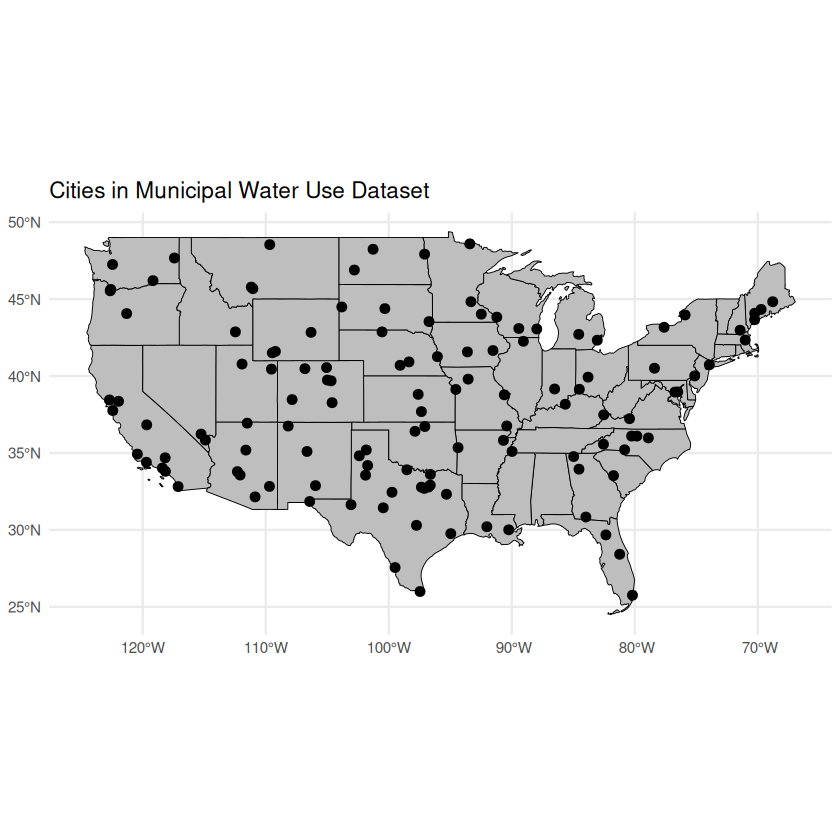

In [24]:
#plot cities shapefile
ggplot()+
    geom_sf(data= US_shp_clean, color = "black", fill = "gray")+ 
    geom_sf(data = city_char_shp_clean, fill= "white", size = 2)+
    labs(title = "Cities in Municipal Water Use Dataset") +
    theme_minimal() 

#visually the data look nicely distributed across the country but hard to say if there are any standout cities missing from the municial dataset. From the unique list of cities there are noteable omissions, including Chicago, IL

## Exploratory Data Analsis

I am interested in per capita residential water use trends across these cities. Residential water use is already separated out in the original municipal water use dataset. I am going to explore how population and climate region could be related to residential water use, below. The results of this EDA will inform any analysis to explain residential water use.

date,res_billed_gallons_sum,population_sum
<date>,<dbl>,<dbl>
2005-01-01,32751881461,17951814
2005-02-01,29534102511,17951814
2005-03-01,31005695599,17951814
2005-04-01,35552273867,17951814
2005-05-01,40641155665,17951814
2005-06-01,49200895027,17951814


`geom_smooth()` using formula = 'y ~ x'


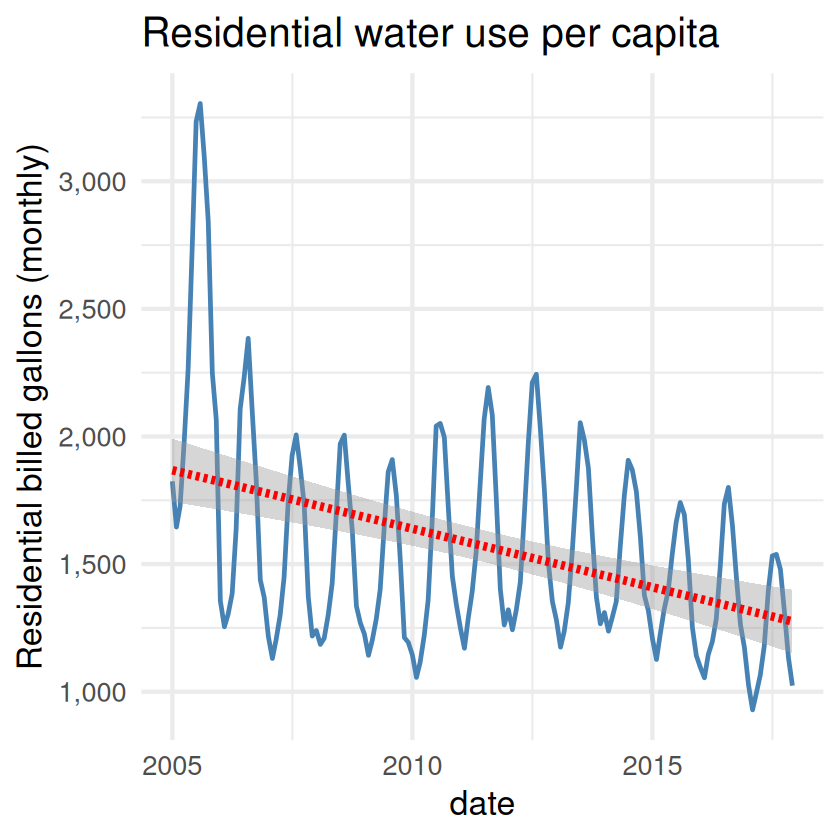

In [60]:
#plot monthly residential water use per capita
monthly_res_total <- muni_water_clean%>%
  #  filter(year >= 2010)%>% #filter to timeframe that lagged population indicator variable will show
    group_by(date)%>%
    summarise(
            res_billed_gallons_sum = sum(res_billed_gallons, na.rm = TRUE),
            population_sum = sum(population, na.rm = TRUE)
        )

head(monthly_res_total)

# Quick plot of original residential data by month
ggplot(monthly_res_total, aes(x = date, y = res_billed_gallons_sum/population_sum)) +
    geom_line(color = "steelblue", linewidth = 1) +       # Line
    geom_smooth(method = "lm", se = TRUE, color = "red", linetype = "dashed") +     # trendline
        labs(
            title = "Residential water use per capita",
            x = "date",
            y = "Residential billed gallons (monthly)"
        ) +
scale_y_continuous(labels = comma) +
theme_minimal(base_size = 20)  

This immediately suggests to me that per capita water use is going down but it is not that helpful to look all of the cities combined, the data needs to be separated by city characteristics

In [49]:
#join city characteristics to residential muni water use dataset to explore relationships

#get muni_water_clean dataset
head(muni_water_clean)

#separate out state and city in city characteristics dataset
city_char_clean<-city_char_clean%>%
    mutate(
        state = str_extract(city, "(?<=, ).*"), #extract text before comma
        city_name = sub(",.*", "", city)
          )

head(city_char_clean)

,us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,month_index,pop_eoy
,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,1600000US4801000,"Abilene, Texas",2005-01-01,120267,193610000,202640000,64870000,461120000,2005,1,NA
2,1600000US4801000,"Abilene, Texas",2005-02-01,120267,168050000,198560000,51900000,418510000,2005,2,NA
3,1600000US4801000,"Abilene, Texas",2005-03-01,120267,158100000,161420000,47580000,367100000,2005,3,NA
4,1600000US4801000,"Abilene, Texas",2005-04-01,120267,190420000,191640000,68730000,450790000,2005,4,NA
5,1600000US4801000,"Abilene, Texas",2005-05-01,120267,260170000,210640000,68170000,538980000,2005,5,NA
6,1600000US4801000,"Abilene, Texas",2005-06-01,120267,283130000,227100000,102870000,613100000,2005,6,NA


,us_census_id,city,cii_res,us_census_region,climate_region,avg_population,january_precipitation,february_precipitation,march_precipitation,april_precipitation,⋯,percent_housing_units_built_earlier_to_1990,median_rooms,percent_impervious_area,area_open_nlcd,area_low_development_nlcd,area_medium_development_nlcd,area_high_development_nlcd,service_area_sq_meters,state,city_name
,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,1600000US4801000,"Abilene city, Texas",0.727,South,Temperate,123729,25.9,35.6,42.5,45.8,⋯,78.0,5.3,16.4,13874.8,10720.6,6208.8,3755.7,290335000,Texas,Abilene city
2,1600000US4500550,"Aiken city, South Carolina",NA,South,Temperate,29406,110.8,103.6,111.3,84.8,⋯,56.7,6.0,9.0,7626.2,6274.4,1805.4,573.7,194774000,South Carolina,Aiken city
3,1600000US3501780,"Alamogordo city, New Mexico",0.205,West,Arid,32986,17.7,12.9,9.5,8.9,⋯,73.8,5.4,14.4,1792.0,3050.2,965.0,208.4,56002000,New Mexico,Alamogordo city
4,1600000US3502000,"Albuquerque city, New Mexico",0.380,West,Arid,614980,10.8,11.8,14.6,17.3,⋯,64.8,5.3,26.9,11553.2,32002.9,24592.5,5344.4,489188000,New Mexico,Albuquerque city
5,1600000US4202184,"Altoona city, Pennsylvania",0.454,Northeast,Continental,54369,65.2,55.3,79.2,80.0,⋯,95.8,6.1,18.9,4855.7,6346.8,3384.4,1673.1,131990000,Pennsylvania,Altoona city
6,1600000US4803000,"Amarillo city, Texas",0.653,South,Arid,196728,17.0,15.3,30.3,32.7,⋯,77.2,5.1,25.2,7145.7,19825.2,7535.3,4717.4,266556000,Texas,Amarillo city


In [50]:
#select us_census_id, city, climate_region, avg_population variables from city_char_clean
city_char_clean_small<-city_char_clean%>%
    select(us_census_id, city_name, climate_region, avg_population)

head(city_char_clean_small)

,us_census_id,city_name,climate_region,avg_population
,<chr>,<chr>,<chr>,<int>
1,1600000US4801000,Abilene city,Temperate,123729
2,1600000US4500550,Aiken city,Temperate,29406
3,1600000US3501780,Alamogordo city,Arid,32986
4,1600000US3502000,Albuquerque city,Arid,614980
5,1600000US4202184,Altoona city,Continental,54369
6,1600000US4803000,Amarillo city,Arid,196728


In [51]:
#left join city characteristics to muni dataset (keep all muni records, only city characteristics that match)
muni_water_clean_city <- left_join(muni_water_clean,city_char_clean_small, by = "us_census_id")   #do NOT use city, IT IS DIFFERENT IN EACH DATASET

head(muni_water_clean_city)

,us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,month_index,pop_eoy,city_name,climate_region,avg_population
,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<chr>,<int>
1,1600000US4801000,"Abilene, Texas",2005-01-01,120267,193610000,202640000,64870000,461120000,2005,1,NA,Abilene city,Temperate,123729
2,1600000US4801000,"Abilene, Texas",2005-02-01,120267,168050000,198560000,51900000,418510000,2005,2,NA,Abilene city,Temperate,123729
3,1600000US4801000,"Abilene, Texas",2005-03-01,120267,158100000,161420000,47580000,367100000,2005,3,NA,Abilene city,Temperate,123729
4,1600000US4801000,"Abilene, Texas",2005-04-01,120267,190420000,191640000,68730000,450790000,2005,4,NA,Abilene city,Temperate,123729
5,1600000US4801000,"Abilene, Texas",2005-05-01,120267,260170000,210640000,68170000,538980000,2005,5,NA,Abilene city,Temperate,123729
6,1600000US4801000,"Abilene, Texas",2005-06-01,120267,283130000,227100000,102870000,613100000,2005,6,NA,Abilene city,Temperate,123729


#### NOTE: Joining small city characteristics dataset to city point data
Now that I have the small city characteristics dataset, I am joining it with the city point data ASAP so it's ready to go for future visualizations

In [92]:
#prep mapping point data to be symbolized by city characeristics

#join city characteristics tabular data to shapefile
city_char_clean_w_pop_clim <- left_join(city_char_shp_clean, city_char_clean_small, by = "us_census_id") 

`summarise()` has grouped output by 'climate_region'. You can override using
the `.groups` argument.


climate_region,date,res_billed_gallons_sum,population_sum
<chr>,<date>,<dbl>,<dbl>
Arid,2005-01-01,12092313426,5224194
Arid,2005-02-01,11007449346,5224194
Arid,2005-03-01,12212269108,5224194
Arid,2005-04-01,15291236624,5224194
Arid,2005-05-01,18693657243,5224194
Arid,2005-06-01,22789859033,5224194


`geom_smooth()` using formula = 'y ~ x'


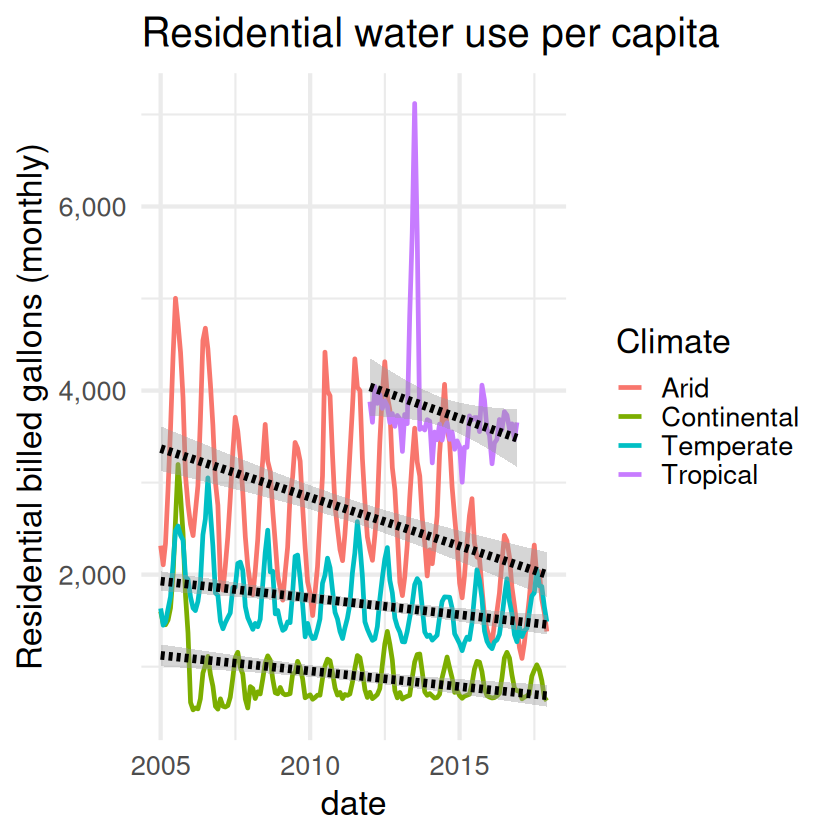

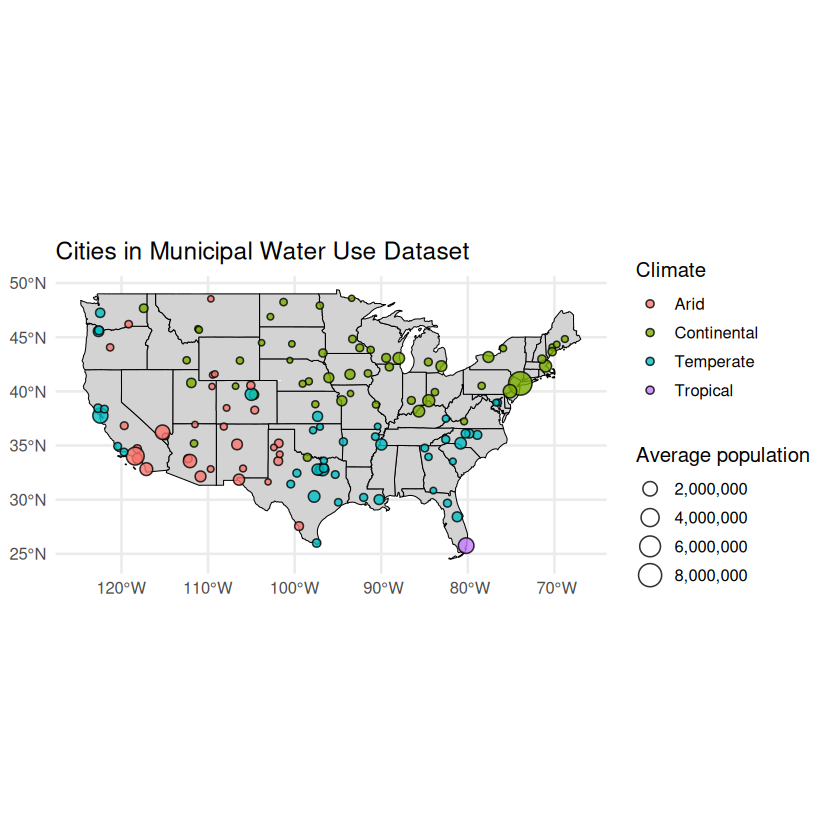

In [96]:
#redo monthly residential water use time series with climate region as a category

#plot monthly residential water use per capita
monthly_res_clim <- muni_water_clean_city%>%
  #  filter(year >= 2010)%>% #filter to timeframe that lagged population indicator variable will show
    group_by(climate_region,date)%>%
    summarise(
            res_billed_gallons_sum = sum(res_billed_gallons, na.rm = TRUE),
            population_sum = sum(population, na.rm = TRUE)
        )

head(monthly_res_clim)

# Quick plot of original residential data by month
ggplot(monthly_res_clim, aes(x = date, y = res_billed_gallons_sum/population_sum, group = climate_region, color = climate_region)) +
    geom_line(linewidth = 1) +       # Line
    geom_smooth(method = "lm", se = TRUE, color = "black", linetype = "dashed") +     # trendline
        labs(
            title = "Residential water use per capita",
            x = "date",
            y = "Residential billed gallons (monthly)",
                color= "Climate"
        ) +
scale_y_continuous(labels = comma) +
theme_minimal(base_size = 20)  

# Map out cities by climate region as well
ggplot()+
    geom_sf(data= US_shp_clean, color = "black", fill = "light gray")+ 
    geom_sf(data = city_char_clean_w_pop_clim, aes(size = avg_population, fill  = climate_region), alpha=0.8, color = "black", shape = 21)+
    labs(title = "Cities in Municipal Water Use Dataset",
        size= "Average population",
        fill= "Climate")+
    theme_minimal(base_size = 12)+
    scale_size_continuous(
        labels = label_comma()
        )
        

There does seem to be a slightly greater rate of declining per capita water use in the arid region cities compared to others. It isn't a huge help in determining what city characteristics are the most relevant. I am going to start looking at population next.

In [63]:
# population indicator variable
muni_water_clean_EDA<- muni_water_clean%>%
left_join(
muni_water_clean %>%
transmute(us_census_id, year = year + 5, pop_5yrs_ago = population)%>%
distinct(),
by = c("us_census_id", "year")
) %>%
group_by(us_census_id)%>%
mutate(
city_big_growth = as.integer(any(
!is.na(pop_5yrs_ago) & (population - pop_5yrs_ago > 100000))
)
)

head(muni_water_clean_EDA
    )

us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,month_index,pop_eoy,pop_5yrs_ago,city_big_growth
<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>
1600000US4801000,"Abilene, Texas",2005-01-01,120267,193610000,202640000,64870000,461120000,2005,1,NA,NA,0
1600000US4801000,"Abilene, Texas",2005-02-01,120267,168050000,198560000,51900000,418510000,2005,2,NA,NA,0
1600000US4801000,"Abilene, Texas",2005-03-01,120267,158100000,161420000,47580000,367100000,2005,3,NA,NA,0
1600000US4801000,"Abilene, Texas",2005-04-01,120267,190420000,191640000,68730000,450790000,2005,4,NA,NA,0
1600000US4801000,"Abilene, Texas",2005-05-01,120267,260170000,210640000,68170000,538980000,2005,5,NA,NA,0
1600000US4801000,"Abilene, Texas",2005-06-01,120267,283130000,227100000,102870000,613100000,2005,6,NA,NA,0


In [64]:
head(muni_water_clean_EDA%>%
     filter(!is.na(pop_5yrs_ago))%>%   
     filter(city_big_growth == 1)
    )


us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,month_index,pop_eoy,pop_5yrs_ago,city_big_growth
<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>
1600000US3502000,"Albuquerque, New Mexico",2010-01-01,630139,1238731384,377146088,58810752,1674688224,2010,1,NA,529358,1
1600000US3502000,"Albuquerque, New Mexico",2010-02-01,630139,1036934448,308707828,43612140,1389254416,2010,2,NA,529358,1
1600000US3502000,"Albuquerque, New Mexico",2010-03-01,630139,1131990672,343132284,59081528,1534204484,2010,3,NA,529358,1
1600000US3502000,"Albuquerque, New Mexico",2010-04-01,630139,1538024884,478478396,186344752,2202848032,2010,4,NA,529358,1
1600000US3502000,"Albuquerque, New Mexico",2010-05-01,630139,1797850164,583788568,252296660,2633935392,2010,5,NA,529358,1
1600000US3502000,"Albuquerque, New Mexico",2010-06-01,630139,2380756840,728109932,396608300,3505475072,2010,6,NA,529358,1


`summarise()` has grouped output by 'city_big_growth'. You can override using
the `.groups` argument.


city_big_growth,date,res_billed_gallons_sum,population_sum
<int>,<date>,<dbl>,<dbl>
0,2010-01-01,26152625934,15849193
0,2010-02-01,23976494461,15849193
0,2010-03-01,24793966983,15849193
0,2010-04-01,26469951239,15849193
0,2010-05-01,29346165194,15849193
0,2010-06-01,35928303874,15849193


`geom_smooth()` using formula = 'y ~ x'


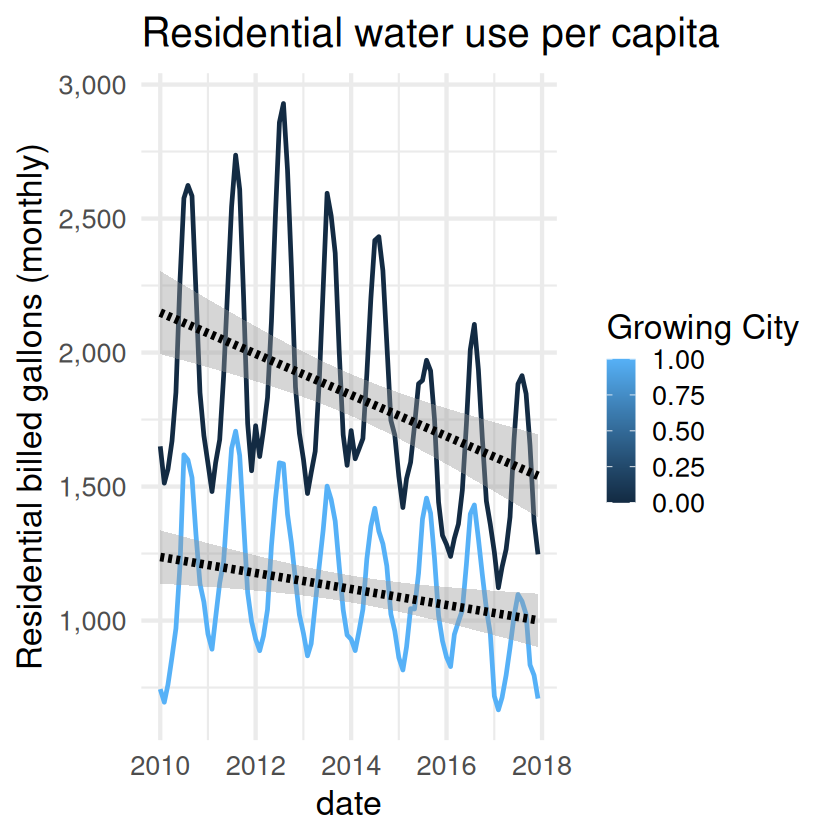

In [146]:
#redo monthly residential water use time series with population indicator as a category

#plot monthly residential water use per capita
monthly_res_pop <- muni_water_clean_EDA%>%
    filter(year >= 2010)%>% #filter to timeframe that lagged population indicator variable will show
    group_by(city_big_growth,date)%>%
    summarise(
            res_billed_gallons_sum = sum(res_billed_gallons, na.rm = TRUE),
            population_sum = sum(population, na.rm = TRUE)
        )

head(monthly_res_pop)

# Plot data
ggplot(monthly_res_pop, aes(x = date, y = res_billed_gallons_sum/population_sum, group = city_big_growth, color = city_big_growth)) +
    geom_line(linewidth = 1) +       # Line
    geom_smooth(method = "lm", se = TRUE, color = "black", linetype = "dashed") +     # trendline
        labs(
            title = "Residential water use per capita",
            x = "date",
            y = "Residential billed gallons (monthly)",
                color= "Growing City"
        ) +
scale_y_continuous(labels = comma) +
theme_minimal(base_size = 20)  

In [68]:
#might also be helpful to see time series at annual time steps

# get annual water use dataset
annual_res <- muni_water_clean_EDA%>%
    group_by(city_big_growth,year) %>%       #collapse monthly dataset into annual without any cities, just climate region
    summarise(
        res_gal= sum(res_billed_gallons, na.rm= TRUE),
        cii_gal= sum(cii_billed_gallons, na.rm= TRUE),
        master_gal= sum(master_billed_gallons, na.rm= TRUE),
        total_gal= sum(total_billed_gallons, na.rm= TRUE),
        total_pop= sum(pop_eoy, na.rm= TRUE)      #use end of year population
    )

head(annual_res)


`summarise()` has grouped output by 'city_big_growth'. You can override using
the `.groups` argument.


city_big_growth,year,res_gal,cii_gal,master_gal,total_gal,total_pop
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,2005,279343997650,168929525963,12401398583,510548415096,9676786
0,2006,334212200992,211785087836,25421946473,624166955365,11559926
0,2007,336331789199,219031868375,25621805588,670403730677,12609470
0,2008,367605829095,253627068597,24669216453,731664760336,14509657
0,2009,364698665473,238819173868,24990906375,715670841468,15026683
0,2010,381517582103,251810327100,26318371059,745138940572,15849193


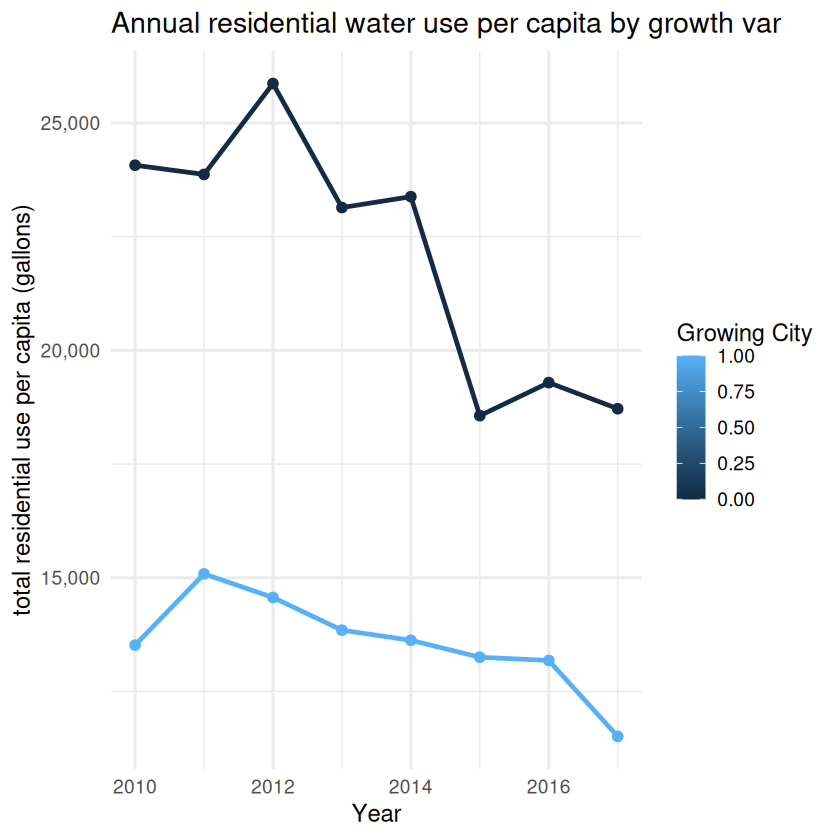

In [147]:
#filter dataset to when it is meaningful- 2010-2017
annual_res_graph<- annual_res%>%
    filter(year >=2010)

#plot annual by indicator
ggplot(annual_res_graph,aes(x = year, y = res_gal/total_pop, group = city_big_growth, color = city_big_growth)) +
    geom_line(linewidth = 1) +
    geom_point(size =2)+
    labs(
    title = "Annual residential water use per capita by growth var",
    x = "Year",
    y = "total residential use per capita (gallons)",
        color = "Growing City"
  ) +
    scale_y_continuous(labels = comma) +
  theme_minimal(base_siz=14)

In [79]:
#look at how many cities meet the current indicator variable standard

#filter df to observations where indicator variable = 1
muni_water_clean_EDA_1 <- muni_water_clean_EDA%>%
    filter(city_big_growth == 1)

unique_big_cities <- unique(muni_water_clean_EDA_1$us_census_id)

,us_census_id,city,latitude,longitude,city_name,climate_region,avg_population,geometry
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>,<POINT [°]>
1,1600000US3502000,"Albuquerque city, New Mexico",35.10,-106.65,Albuquerque city,Arid,614980,POINT (-106.65 35.1)
2,1600000US4805000,"Austin city, Texas",30.30,-97.75,Austin city,Temperate,903672,POINT (-97.75 30.3)
3,1600000US2507000,"Boston city, Massachusetts",42.34,-71.02,Boston city,Continental,1047462,POINT (-71.02 42.34)
4,1600000US3712000,"Charlotte city, North Carolina",35.21,-80.83,Charlotte city,Temperate,864289,POINT (-80.83 35.21)
5,1600000US4819000,"Dallas city, Texas",32.79,-96.77,Dallas city,Temperate,1236107,POINT (-96.77 32.79)
6,1600000US4827000,"Fort Worth city, Texas",32.78,-97.35,Fort Worth city,Temperate,759416,POINT (-97.35 32.78)
7,1600000US3240000,"Las Vegas city, Nevada",36.23,-115.26,Las Vegas city,Arid,1970912,POINT (-115.26 36.23)
8,1600000US2148006,"Louisville/Jefferson County metro government (balance), Kentucky",38.17,-85.65,Louisville/Jefferson County metro government (balance),Continental,895770,POINT (-85.65 38.17)
9,1600000US3651000,"New York city, New York",40.73,-73.94,New York city,Continental,8327118,POINT (-73.94 40.73)


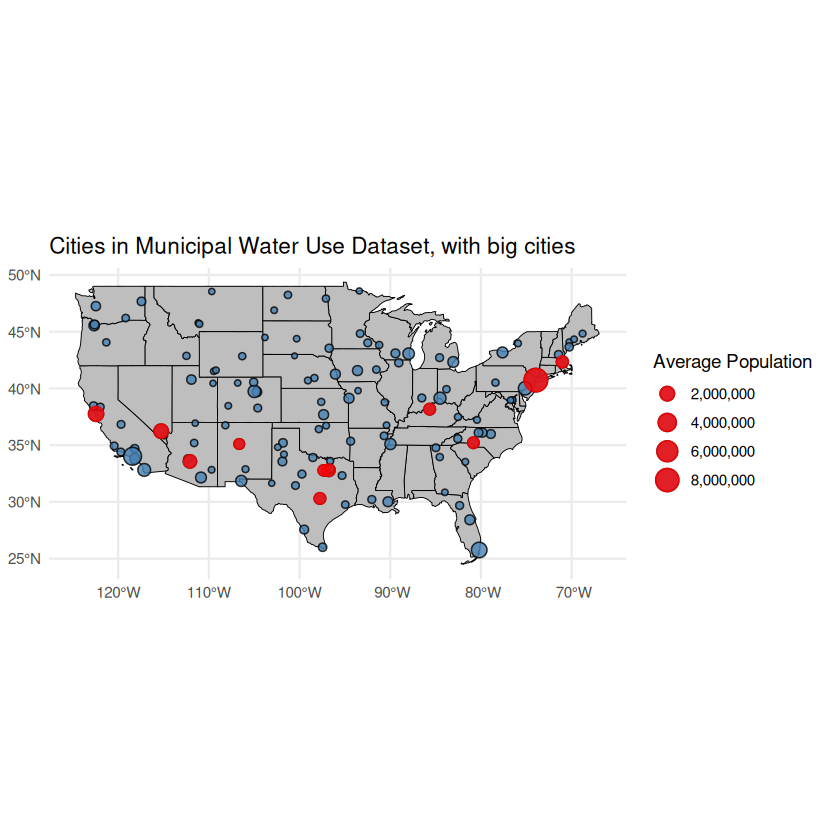

In [90]:
#plot cities that meet the current population indicator, show pts based on average population

#get point data for big cities
city_pts_big <- city_char_clean_w_pop_clim%>%
    filter(us_census_id %in% unique_big_cities)

city_pts_big

#plot cities shapefile
ggplot()+
    geom_sf(data= US_shp_clean, color = "black", fill = "gray")+ 
    geom_sf(data = city_char_clean_w_pop_clim, aes(size = avg_population), alpha=0.8, fill = "steel blue", color = "black", shape = 21)+
    geom_sf(data = city_pts_big, aes(size = avg_population), alpha=0.8, fill = "red", color = "red", shape = 21)+
    labs(title = "Cities in Municipal Water Use Dataset, with big cities",
        size = "Average Population"
        ) +
    scale_size_continuous(
        labels = label_comma()
        )+
    theme_minimal() 

### Population growth discussion
- 11/126 cities meet the current indicator variable standard. See map for geographic spread and relative size of cities
-  Cities that grew over this time period use less water per capita
- Cities that were not growing used more water per capita in 2010 but also dropped in per capita waer use more rapidly than the growing cities
- The "city_big_growth" indicator gives a 1 if there was any point where 100,000 people were added in a 5-year period for a city. This fixed threshold might be too high for smaller cities that still experienced a high population increase relative to their starting point
- Next step: Analysis

## Analysis

Having established a clear distinction in residential water use with the city growth variable, it would be interesting to understand the relationship further. The EDS mentors recommended a fixed OLS model approach to doing just that. With this model, it is possible to include fixed effects that are time-invariant.

In [140]:
muni_water_clean_analysis <- muni_water_clean_EDA

In [141]:
#fixed effect OLS model to explain residential water use

#model <- feols(y ~ x1 + x2 | fixed_effect_var, data = data)

model <- 
feols(log(res_billed_gallons) ~ city_big_growth,      #take log of residential water use to get more stability
               data = muni_water_clean_analysis)

summary(model)

NOTE: 3,047 observations removed because of NA values (LHS: 3,047).



OLS estimation, Dep. Var.: log(res_billed_gallons)
Observations: 13,258
Standard-errors: IID 
                Estimate Std. Error   t value  Pr(>|t|)    
(Intercept)     19.15374   0.011896 1610.1086 < 2.2e-16 ***
city_big_growth  2.17669   0.035946   60.5539 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 1.29246   Adj. R2: 0.216618

### Modeling Discussion
- My dependent variable is the log-transformed residential water use.
- The city_big_growth variable is a binary variable representing if a city added 100,000 people in any 5 year increment in the time series.
- In this model, the coefficient of 2.1766 for the city_big_growth independent variable represents the ~217% change in residential water use between a city that did experience that growth vs one that did not. This result is statistically significant.
- Overall the model



#### NOTE: Following March 17 capstone presentation, additional work was suggested which has been incorporated throughout this notebook. The last suggestion was to develop an indicator variable that shows relative growth instead of an fixed number. Initial work has begun on incorporating this but it is not complete. Code is included below to demonstrate receptiveness to the great suggestion!

Thank you for this experience, YSE instructors!

In [149]:
#develop an indicator variable that shows relative growth-- yearly growth of 4%

pop_yearly <- muni_water_clean %>%
group_by(us_census_id, year) %>%
summarize(population = first(population), .groups = "drop")%>%
arrange(us_census_id,year) %>% 
group_by(us_census_id) %>%
mutate(
pop_lag = lag(population),
growth_rate = (population - pop_lag) / pop_lag
) %>%
mutate(
city_big_growth_percent = as.integer(
growth_rate > 0.04, na.rm = TRUE
)
) %>%
ungroup()

head(pop_yearly)

muni_water_clean_analysis_rate <- muni_water_clean %>%
left_join(pop_yearly %>% select(us_census_id, year, growth_rate, city_big_growth_percent),
by = c("us_census_id", "year"))

head(muni_water_clean_EDA_rate%>%
    filter(city_big_growth_percent == 0
    ))


unique(muni_water_clean_analysis_rate$city_big_growth_percent)

us_census_id,year,population,pop_lag,growth_rate,city_big_growth_percent
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1600000US0423620,2011,66660,NA,NA,NA
1600000US0423620,2012,67393,66660,0.01099610,0
1600000US0423620,2013,68135,67393,0.01101005,0
1600000US0423620,2014,68884,68135,0.01099288,0
1600000US0423620,2015,70643,68884,0.02553568,0
1600000US0423620,2016,71656,70643,0.01433971,0


,us_census_id,city,date,population,res_billed_gallons,cii_billed_gallons,master_billed_gallons,total_billed_gallons,year,month_index,pop_eoy,growth_rate,city_big_growth_percent
,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>
1,1600000US4801000,"Abilene, Texas",2006-01-01,121135,225112000,189011000,71316000,485439000,2006,1,NA,0.007217275,0
2,1600000US4801000,"Abilene, Texas",2006-02-01,121135,206907000,183474000,60479000,450860000,2006,2,NA,0.007217275,0
3,1600000US4801000,"Abilene, Texas",2006-03-01,121135,198771000,174106000,63024000,435901000,2006,3,NA,0.007217275,0
4,1600000US4801000,"Abilene, Texas",2006-04-01,121135,229799000,204717000,76911000,511427000,2006,4,NA,0.007217275,0
5,1600000US4801000,"Abilene, Texas",2006-05-01,121135,275565000,218790000,65836000,560191000,2006,5,NA,0.007217275,0
6,1600000US4801000,"Abilene, Texas",2006-06-01,121135,346775000,255700000,110890000,713365000,2006,6,NA,0.007217275,0


[1] NA  0  1

`summarise()` has grouped output by 'city_big_growth_percent'. You can override
using the `.groups` argument.


city_big_growth_percent,date,res_billed_gallons_sum,population_sum
<int>,<date>,<dbl>,<dbl>
0,2010-01-01,35285844218,30694863
0,2010-02-01,32420079358,30694863
0,2010-03-01,34512538324,30694863
0,2010-04-01,37204480055,30694863
0,2010-05-01,41980498597,30694863
0,2010-06-01,51436832675,30694863


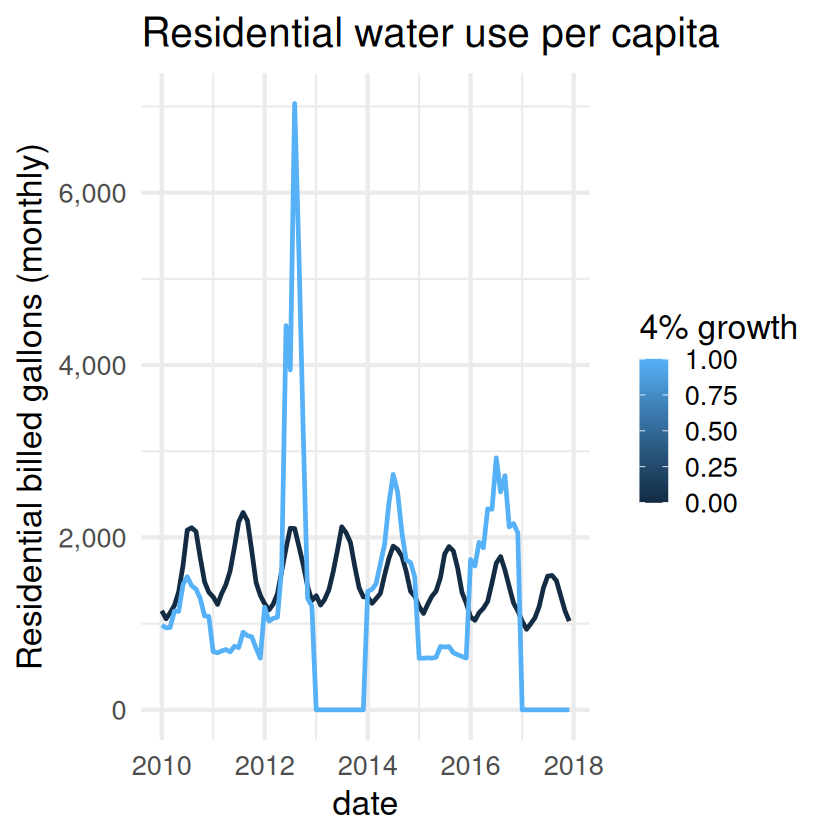

In [151]:
#redo monthly residential water use time series with population indicator as a category

#plot monthly residential water use per capita
monthly_res_pop_2 <- muni_water_clean_analysis_rate%>%
    filter(year >= 2010 & !is.na(city_big_growth_percent))%>% #filter to timeframe that lagged population indicator variable will show
    group_by(city_big_growth_percent,date)%>%
    summarise(
            res_billed_gallons_sum = sum(res_billed_gallons, na.rm = TRUE),
            population_sum = sum(population, na.rm = TRUE)
        )

head(monthly_res_pop_2)

# Plot data
ggplot(monthly_res_pop_2, aes(x = date, y = res_billed_gallons_sum/population_sum, group = city_big_growth_percent, color = city_big_growth_percent)) +
    geom_line(linewidth = 1) +       # Line
        labs(
            title = "Residential water use per capita",
            x = "date",
            y = "Residential billed gallons (monthly)",
                color= "4% growth"
        ) +
scale_y_continuous(labels = comma) +
theme_minimal(base_size = 20)   

In [152]:
#fixed effect OLS model to explain residential water use

#model <- feols(y ~ x1 + x2 | fixed_effect_var, data = data)

model_2 <- 
feols(log(res_billed_gallons) ~ city_big_growth_percent,      #take log of residential water use to get more stability
               data = muni_water_clean_analysis_rate)

summary(model_2)

NOTE: 4,268 observations removed because of NA values (LHS: 3,047, RHS: 1,503).



OLS estimation, Dep. Var.: log(res_billed_gallons)
Observations: 12,037
Standard-errors: IID 
                         Estimate Std. Error    t value   Pr(>|t|)    
(Intercept)             19.370419   0.013558 1428.74170  < 2.2e-16 ***
city_big_growth_percent  0.484525   0.063310    7.65317 2.1103e-14 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 1.45283   Adj. R2: 0.00476